# East-Central Minnesota Batholith ca. 1779 Ma paleomagnetic pole

## Geologic context

The East-Central Minnesota Batholith (ECMB) is a *ca.* 1780 Ma suite of felsic to
intermediate plutons (including the St. Cloud, Rockville, Reformatory, and Richmond
granites) emplaced along the southeastern margin of the Superior
Province following the accretionary Penokean orogeny. Mafic
melt generated during batholith assembly was emplaced as a set of vertical,
northeast-trending diabase dikes that intrude all of the ECMB granitoids except
the youngest Richmond Granite. The dikes are 1–8 m wide with chilled margins,
retain primary igneous textures with no metamorphic fabric, and are comagmatic
with the batholith (one quartz–feldspar–porphyry dike commingles with a diabase
dike; Boerboom, 2000, 2005). Field relations show the dikes are younger than the
St. Cloud Granite they intrude and older than the Richmond Granite, which lacks
them.

## Pole context

A high-quality paleomagnetic pole from these dikes is the first well-dated pole
from the Superior Province *following* Trans-Hudson orogenesis. Its similarity to
*ca.* 1780 Ma poles from the Slave and Rae provinces establishes the coherency of
Laurentia after assembly, and it supports the NENA (northern Europe–North
America) connection between Laurentia and Fennoscandia within the hypothesized
supercontinent Nuna (Swanson-Hysell et al., 2021).

## Paleomagnetic and rock magnetic data

Stepwise alternating-field and thermal demagnetization resolve three
components in the dikes: a low-coercivity present-field overprint (`lc`), the
medium-coercivity characteristic remanent magnetization (`mc`) held by magnetite, and a variably present 
high-coercivity Midcontinent Rift overprint (`hc`) held by pyrrhotite. The `mc` ChRM is steep and is
thermally unblocked between 515°C and 565°C, consistent with a remanence carried
by low-Ti titanomagnetite (also supported by low-temperature magnetometry). The
pole is computed from the `mc` component of the northeast-trending dikes, keeping
the 23 site means with site-level uncertainty α95 < 8° (following
Swanson-Hysell et al., 2021). A primary, emplacement-age origin for the `mc`
remanence is supported by the rock magnetic data, a positive inverse baked
contact test on a ca. 1096 Ma Midcontinent Rift dike, and thermochronology indicating the intrusions cooled below the
magnetite blocking temperature upon emplacement with only a mild subsequent
thermal history within the stable craton.

Bringing the 23 site VGPs to a common polarity and computing the Fisher mean
gives a pole at 20.5°N, 265.8°E (A95 = 4.5°, K = 45.6, N = 23), reproducing the
published ECMB pole.

## Age constraints

- **1779.1 ± 2.3 Ma (95% CI)** is adopted as the best age for the dikes
  (Swanson-Hysell et al., 2021), constrained by new U-Pb dates that bracket the
  dikes between the St. Cloud Granite (1781.44 ± 0.51 Ma, 2σ) they pervasively
  intrude and the Richmond Granite (1776.76 ± 0.49 Ma) in which they are absent.
- A comagmatic quartz–feldspar–porphyry dike yields 1780.78 ± 0.45 Ma, consistent
  with emplacement of the diabase dikes at this time.

## References

### Paleomagnetism

- Swanson-Hysell, N. L., Avery, M. S., Zhang, Y., Hodgin, E. B., Sherwood, R. J., Apen, F. E., Boerboom, T. J., Keller, C. B., & Cottle, J. M. (2021). The paleogeography of Laurentia in its early years: new constraints from the Paleoproterozoic East-Central Minnesota Batholith. *Tectonics*, 40, e2021TC006751. https://doi.org/10.1029/2021TC006751

### Geochronology

- Swanson-Hysell, N. L., Avery, M. S., Zhang, Y., Hodgin, E. B., Sherwood, R. J., Apen, F. E., Boerboom, T. J., Keller, C. B., & Cottle, J. M. (2021). The paleogeography of Laurentia in its early years: new constraints from the Paleoproterozoic East-Central Minnesota Batholith. *Tectonics*, 40, e2021TC006751. https://doi.org/10.1029/2021TC006751 (U-Pb zircon dates on the St. Cloud Granite, Richmond Granite, and quartz–feldspar–porphyry dikes).

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

The site data come from the published Swanson-Hysell et al. (2021) MagIC
contribution [17072](https://earthref.org/MagIC/17072) (DOI
10.1029/2021TC006751). The site table archives several demagnetization components
per site (`lc`, `mc`, `hc`, with thermal `lt`/`mt`/`ht` fits); the full table is
kept in `../data/1779_East_Central_Minnesota_Batholith/sites.txt` (assembled in
`contribution_build/`, which also adds the pole result to the location table).

The ECMB dikes are near-vertical intrusions reported in **geographic
coordinates** (no structural/tilt correction), so `pt.load_magic_sites` returns
all site means in the geographic frame (`dir_tilt_correction == 0`). We select
the pole sites: the medium-coercivity (`mc`) characteristic remanence of the
northeast-trending dikes, keeping the 23 site means with α95 < 8° and excluding
the ca. 1096 Ma northwest-trending Midcontinent Rift dike `NWD1` (used below for
the baked-contact test; the granite sites carry no `mc` component).

In [2]:
sites_geo, sites_tc = pt.load_magic_sites('../data/1779_East_Central_Minnesota_Batholith/sites.txt')

# pole sites: mc component of the NE-trending dikes with site a95 < 8 deg
sites_pole = sites_geo[(sites_geo['dir_comp_name'] == 'mc') &
                       (sites_geo['site'] != 'NWD1') &
                       (sites_geo['dir_alpha95'] < 8)].reset_index(drop=True)
print(f'{len(sites_pole)} sites in pole')
sites_pole[['site', 'lat', 'lon', 'dir_comp_name',
            'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95',
            'vgp_lat', 'vgp_lon', 'vgp_dp', 'vgp_dm',
            'dir_tilt_correction', 'dir_n_samples']]

23 sites in pole


,site,lat,lon,dir_comp_name,dir_dec,dir_inc,dir_k,dir_alpha95,vgp_lat,vgp_lon,vgp_dp,vgp_dm,dir_tilt_correction,dir_n_samples
0,NED1,45.53423,265.75804,mc,157.6,74.7,380.0,2.8,18.4,276.9,4.6,5.1,0.0,8.0
1,NED10,45.53259,265.75742,mc,199.7,73.3,324.0,3.7,15.8,255.4,5.9,6.6,0.0,6.0
2,NED11,45.53252,265.75768,mc,166.1,75.1,391.0,3.1,18.1,272.6,5.2,5.7,0.0,7.0
3,NED12,45.53489,265.76076,mc,179.5,73.0,374.0,3.5,14.1,266.0,5.6,6.2,0.0,6.0
4,NED13,45.53497,265.76113,mc,169.1,73.9,199.0,4.3,15.9,271.4,7.0,7.8,0.0,7.0
5,NED14,45.53492,265.76119,mc,193.0,70.0,217.0,4.6,10.1,258.0,6.8,7.9,0.0,6.0
6,NED15,45.53688,265.76758,mc,175.8,77.7,604.0,2.3,22.0,267.6,4.0,4.3,0.0,8.0
7,NED16,45.53728,265.76822,mc,185.1,78.6,449.0,3.6,23.6,263.7,6.4,6.8,0.0,5.0
8,NED18,45.53124,265.76945,mc,134.7,81.7,159.0,5.3,33.2,279.5,10.0,10.3,0.0,6.0
9,NED2,45.53421,265.75816,mc,172.3,74.9,420.0,2.7,17.4,269.6,4.5,4.9,0.0,8.0


## Site location map

In [3]:
pt.plot_site_map(sites_pole, zoom_start=12)

## Mean pole from VGPs

Plon: 265.8  Plat: 20.5
Number of directions in mean (n): 23
Angular radius of 95% confidence (A_95): 4.5
Precision parameter (k) estimate: 45.6


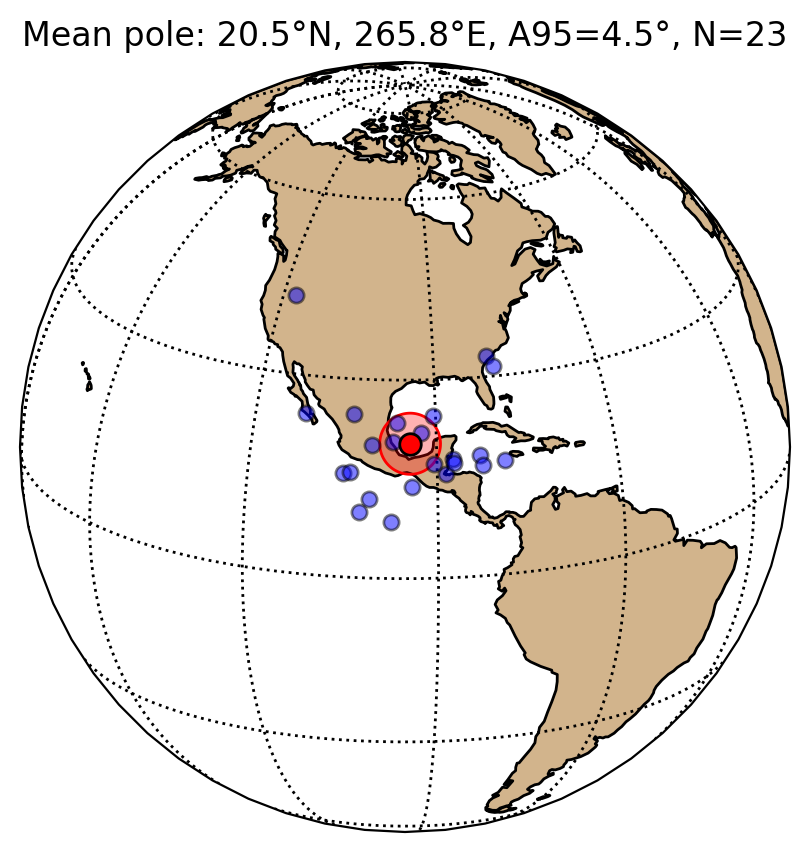

In [4]:
vgp_block, pole_mean = pt.compute_mean_pole(sites_pole, unify_polarity=True)
ipmag.print_pole_mean(pole_mean)
pole_plot = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=265,
                                  central_latitude=20, figsize=(5, 5))

## Site directions (as measured at site)

Dec: 179.9  Inc: 76.7
Number of directions in mean (n): 23
Angular radius of 95% confidence (a_95): 2.5
Precision parameter (k) estimate: 150.3


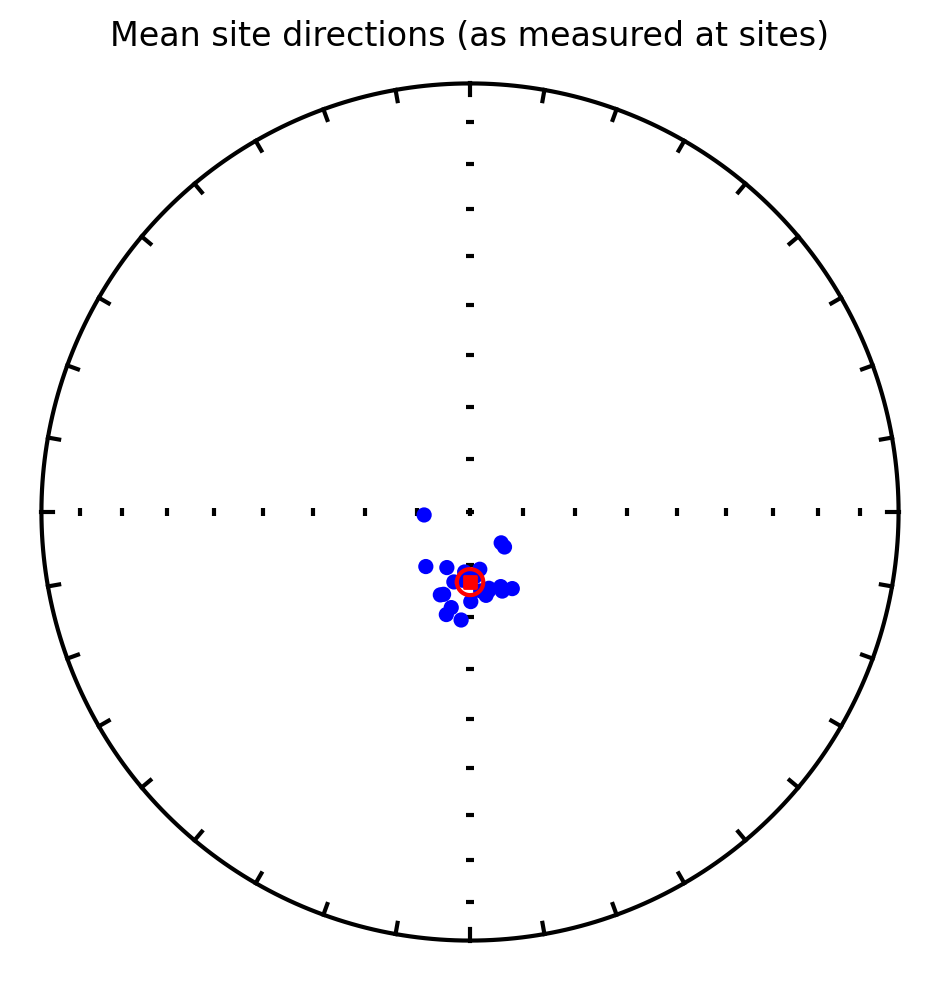

In [5]:
dir_block, dir_mean = pt.compute_mean_direction(sites_pole, unify_polarity=True)

ipmag.print_direction_mean(dir_mean)

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                   color='red', marker='s')
ipmag.plt.title('Mean site directions (as measured at sites)')
ipmag.plt.show()

## Site direction (calculated from VGPs for common site location)

We unite the site VGPs to a common locality at 45.53°N, 265.76°E (the center of
the ECMB dike sampling area near St. Cloud, Minnesota).

Dec: 179.9  Inc: 76.7
Number of directions in mean (n): 23
Angular radius of 95% confidence (a_95): 2.5
Precision parameter (k) estimate: 150.3


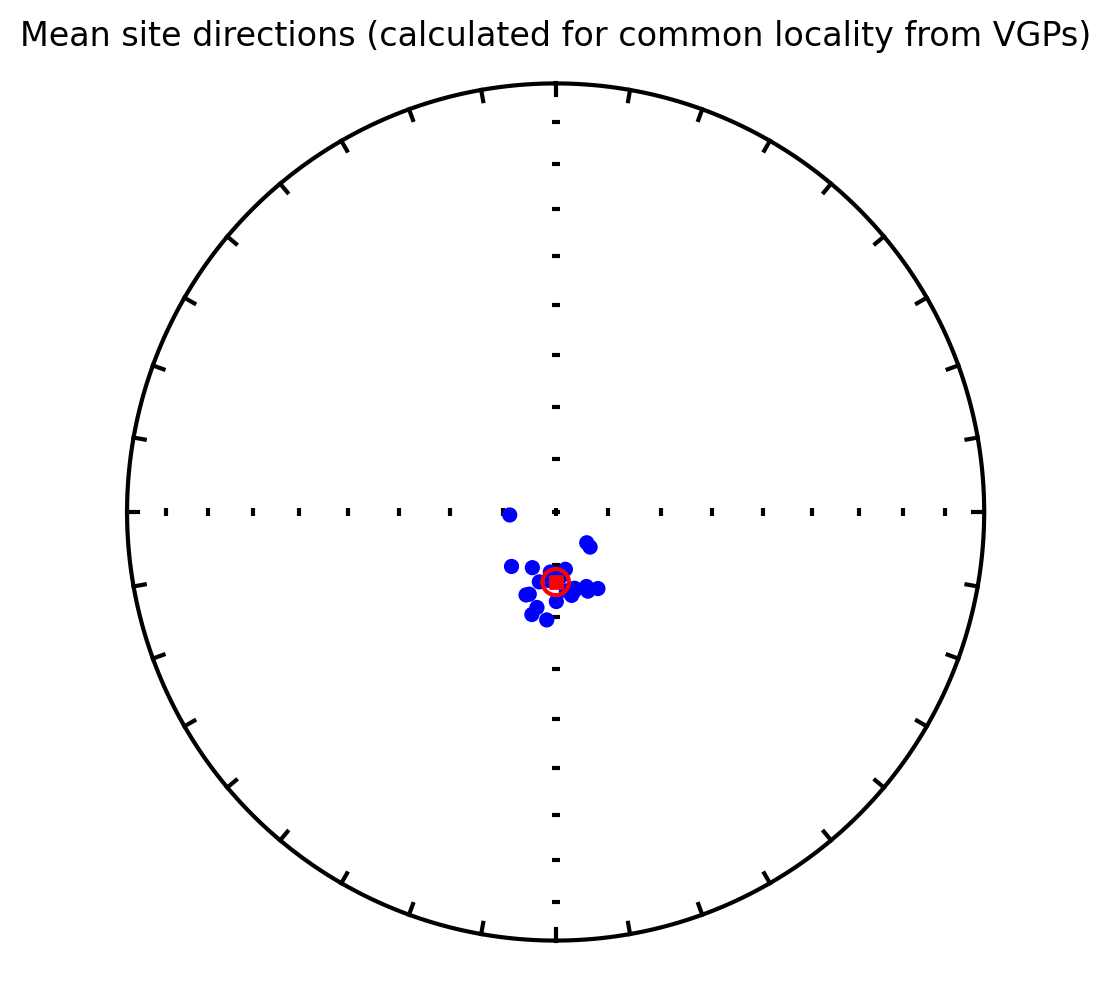

In [6]:
study_lat = 45.53
study_lon = 265.76
dir_block_from_vgps, dir_mean_from_vgps = pt.compute_mean_direction_from_vgps(
    sites_pole, study_lon, study_lat, unify_polarity=True)

ipmag.print_direction_mean(dir_mean_from_vgps)

ipmag.plot_net()
ipmag.plot_di(di_block=dir_block_from_vgps, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean_from_vgps['dec'], dir_mean_from_vgps['inc'],
                   dir_mean_from_vgps['alpha95'], color='red', marker='s')
ipmag.plt.title('Mean site directions (calculated for common locality from VGPs)')
ipmag.plt.show()

## Pole in the context of the Laurentia APWP

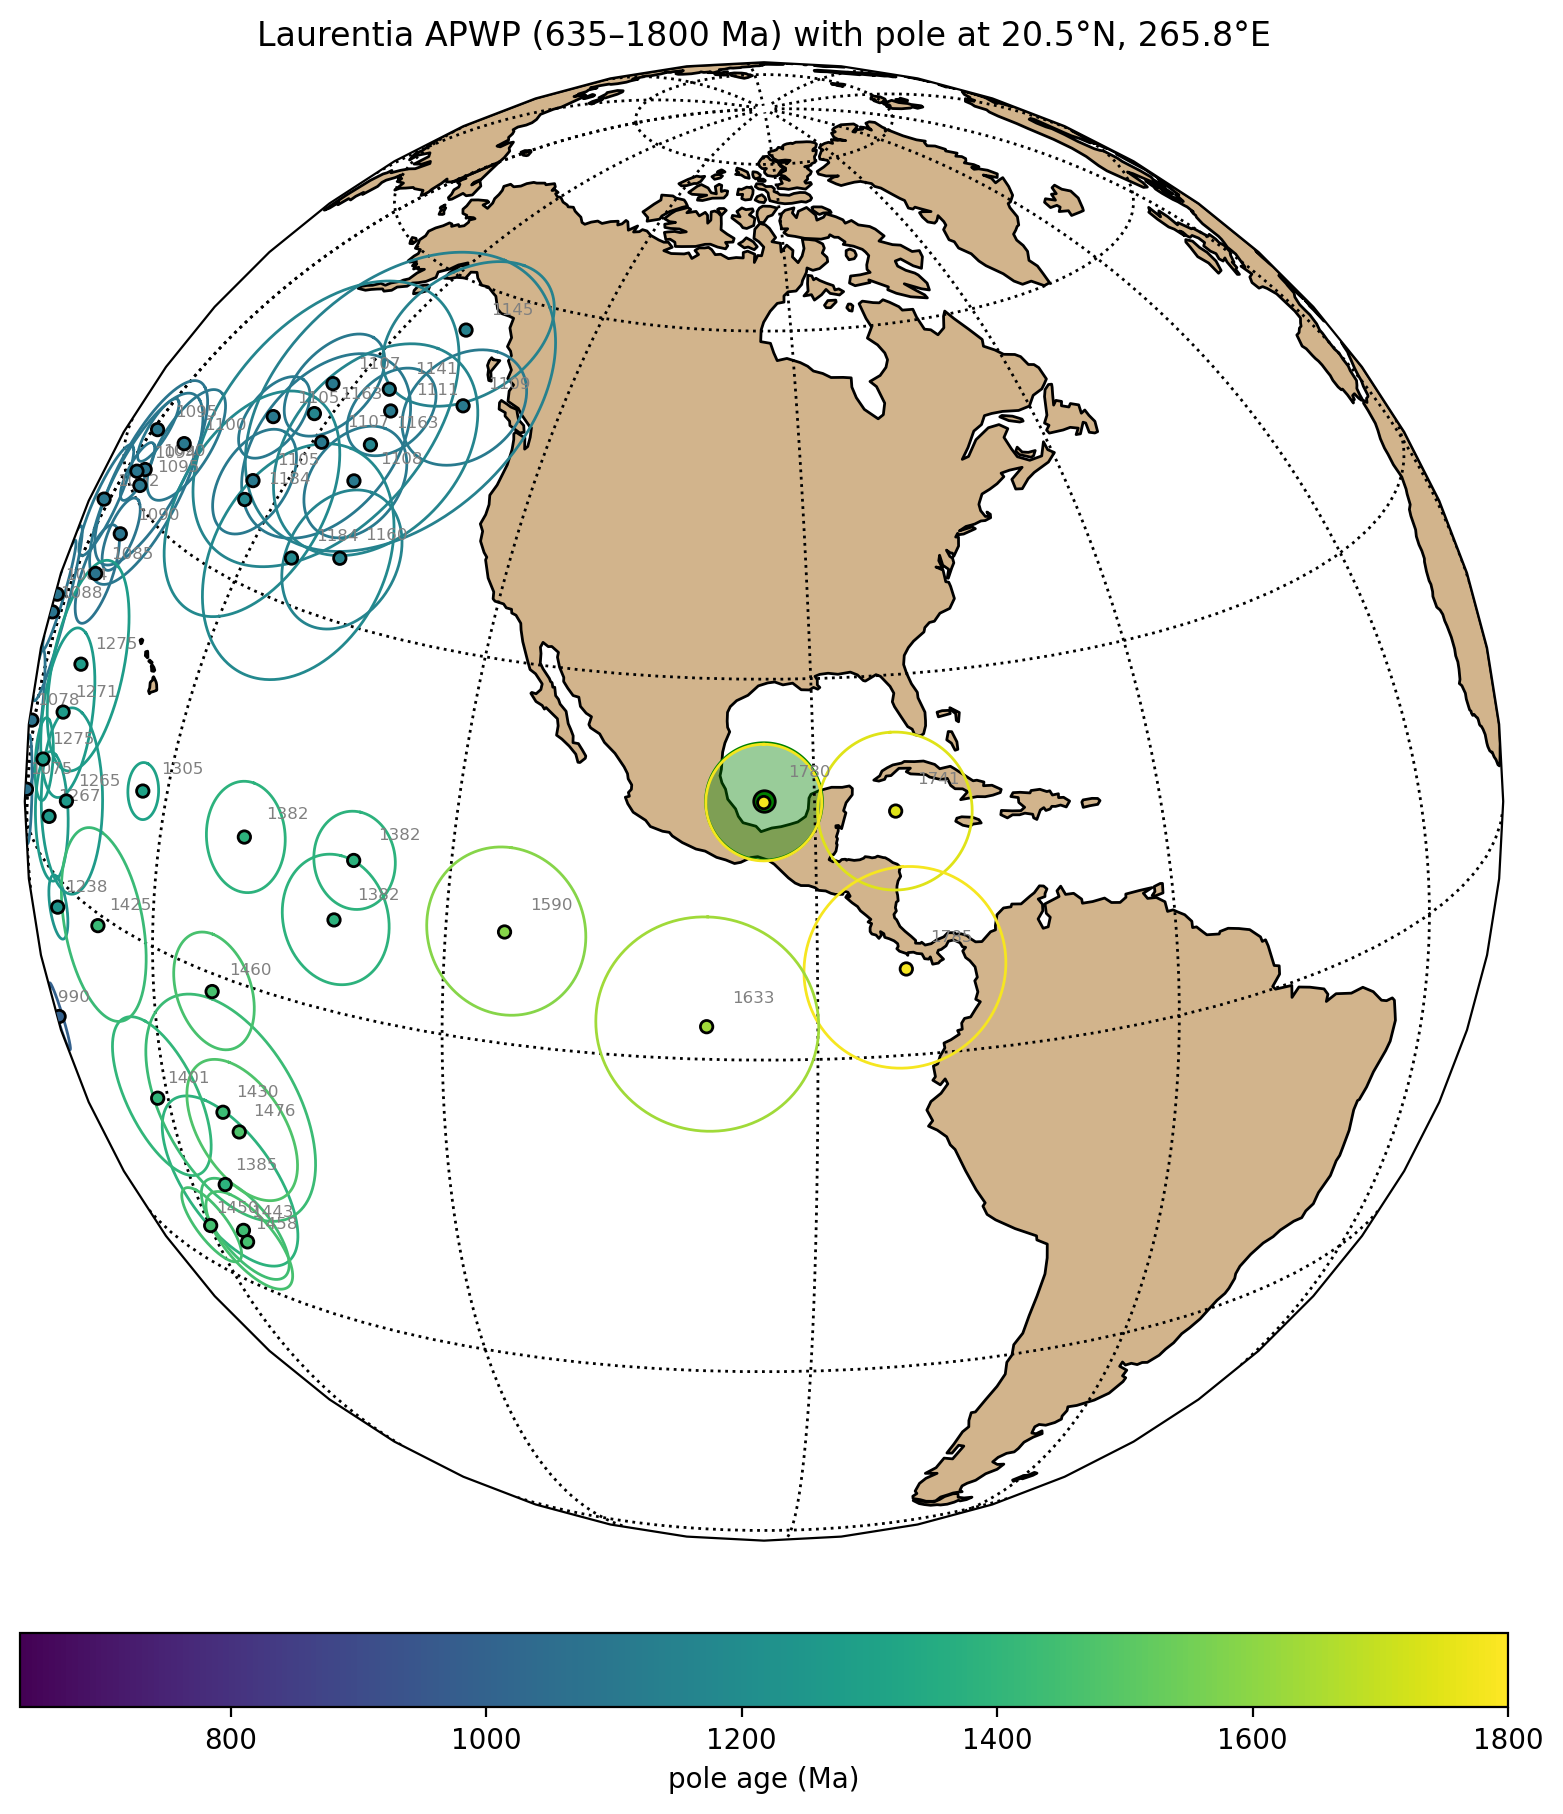

In [7]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_poles = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'], pole_mean['alpha95'], age_min=635, age_max=1800, projection='orthographic', central_longitude=pole_mean['dec'], central_latitude=pole_mean['inc'])
plt.show()

## R2: Techniques and statistical analysis (Meert et al., 2020)

The R2 assessment follows the three sub-criteria of Meert et al. (2020), as set
out in `resources/Meert2020_R_criteria.md`: **(a)** stepwise demagnetization by at
least two methods (AF and thermal); **(b)** component analysis by PCA (best-fit
lines) or great circles; and **(c)** adequate paleosecular-variation (PSV)
sampling. Sub-criteria (a) and (b) are reported here only as *advisory* indicators
read from the MagIC `method_codes`. Both alternating-field and thermal
demagnetization were applied in the study (e.g., the thermal `lt`/`mt`/`ht` fits
at sites NED2, NED17), and components were isolated by principal-component
analysis; the pole-bearing `mc` site means are dominantly AF-derived, so the
automated `method_codes` check reads only AF for this subset. The substantive,
reproducible part of R2 is sub-criterion (c), evaluated from the recreated site
data with the Deenen et al. (2011) A95 envelope on the VGP distribution together
with N ≥ 25 samples, 10 ≤ K ≤ 70, B ≥ 8 sites, and ≥ 3 samples per site.

R2 assessment (Meert et al., 2020):
  (a) two demag methods (AF + thermal)  [advisory, from method_codes]: no
  (b) PCA / great-circle component analysis  [advisory, from method_codes]: yes
      note: method codes are inconsistently applied; confirm (a)/(b) against the source publication.
  (c) adequate PSV sampling [scored]:
        N = 148 samples (>= 25): PASS
        K = 45.6 (10-70): PASS
        B = 23 sites (>= 8): PASS
        min 3 samples/site (>= 3): PASS
        A95 = 4.5 in Deenen envelope [3.4, 11.4]: PASS
  => R2 (from sub-criterion c) = 1

A_95 of 4.5 passes Deenen et al. (2011) criteria of being between 3.4 and 11.4 for this number of sites


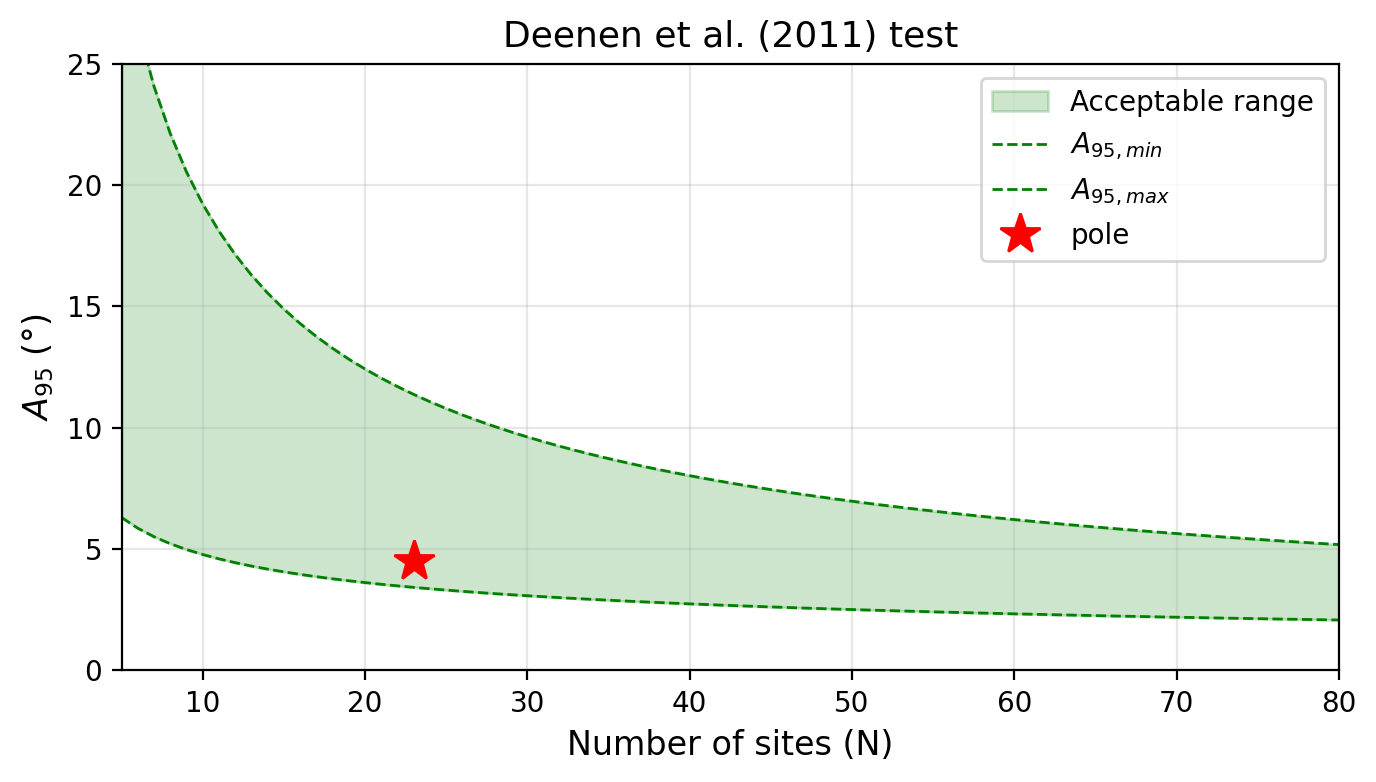

In [8]:
r2 = pt.assess_R2(sites_pole, pole_mean)
print()
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)
plt.show()

### Supplementary: VGP distribution-shape diagnostics (Fisher Q-Q and SVEI)

Beyond the formal R2(c) thresholds above, these tests examine the *shape* of the
VGP distribution as a further check on PSV sampling. The Fisher Q-Q test
(`ipmag.fishqq`) compares the VGP distribution against a Fisher model in its
longitude (uniform) and latitude (exponential) components. The SVEI test
(`pmagpy.svei`) compares the elongation (E) and elongation azimuth (V2dec) of the
directional distribution at the study locality against Monte Carlo realizations of
a giant-Gaussian-process field model (TK03.GAD; Tauxe & Kent, 2004) at the implied
paleolatitude. These are reported as diagnostics, not as a strict reliability
cutoff.

{'Mode': 'Mode 1',
 'Dec': 265.8884717903875,
 'Inc': 20.342047823434047,
 'N': 23,
 'Mu': 1.023012714554172,
 'Mu_critical': 1.207,
 'Me': 0.48715288463815454,
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

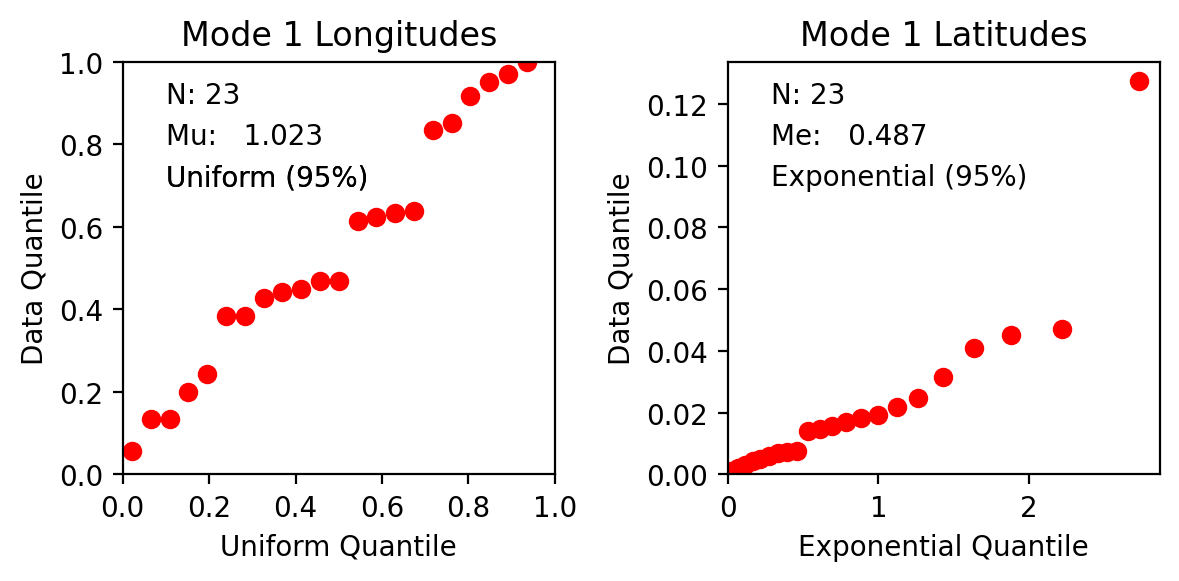

In [9]:
fishqq_result = pt.fishqq_vgps(sites_pole, unify_polarity=True)
fishqq_result

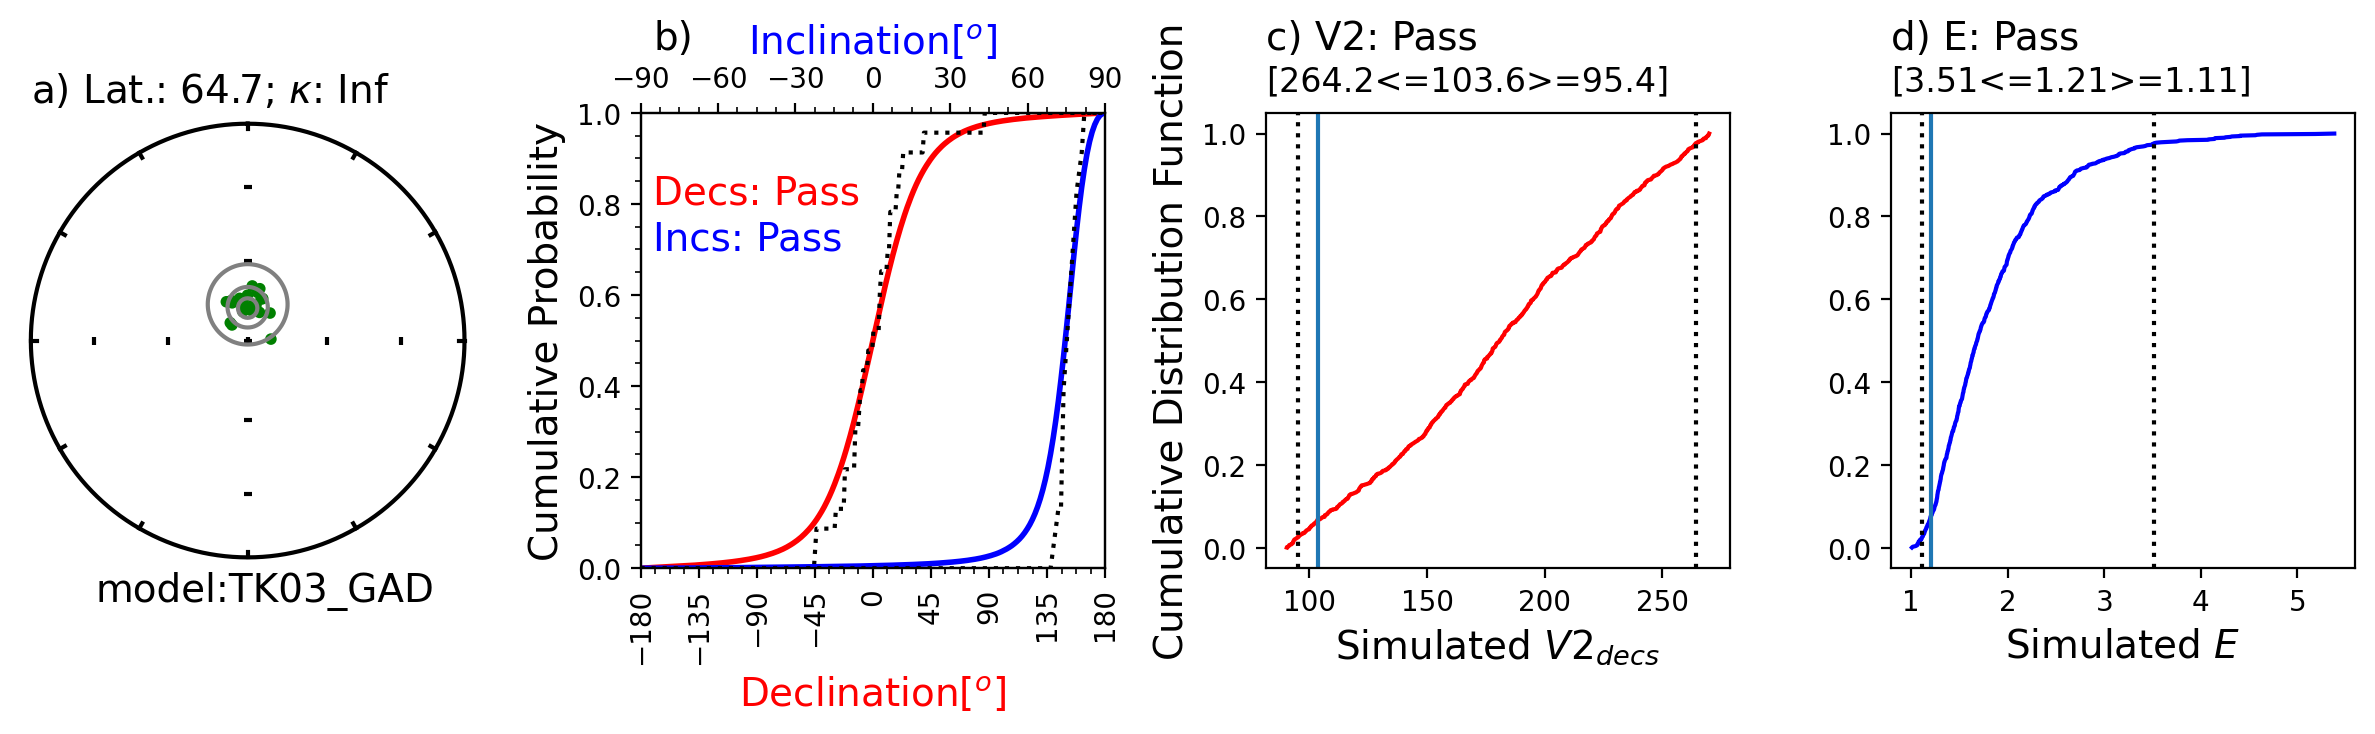

paleolatitude = 64.7°
elongation E = 1.21 (model 95% bounds 1.11–3.51; consistent)
V2 declination = 103.6° (model 95% bounds 95.4–264.2; consistent)


In [10]:
svei_result = pt.svei_test_vgps(sites_pole, study_lon, study_lat, model='TK03_GAD', plot=True)
print(f"paleolatitude = {svei_result['lat']:.1f}°")
print(f"elongation E = {svei_result['E']:.2f} "
      f"(model 95% bounds {svei_result['Esim_min']:.2f}–{svei_result['Esim_max']:.2f}; "
      f"{'consistent' if svei_result['E_result'] else 'inconsistent'})")
print(f"V2 declination = {svei_result['V2dec']:.1f}° "
      f"(model 95% bounds {svei_result['V2sim_min']:.1f}–{svei_result['V2sim_max']:.1f}; "
      f"{'consistent' if svei_result['V2_result'] else 'inconsistent'})")

Both diagnostics are consistent with adequately-sampled paleosecular
variation. The Fisher Q-Q test finds the VGP distribution consistent with a Fisher
distribution (the uniform-longitude Mu and exponential-latitude Me statistics both
fall below their critical values). The SVEI test, at the implied paleolatitude
(~65°), finds an elongation magnitude (E ≈ 1.2) and an elongation azimuth (V2dec)
that are both consistent with the TK03.GAD field model. Together with the Deenen
et al. (2011) envelope, these indicate that the 23 dike site means provide an
adequate average of geomagnetic secular variation.

## R7: Comparison with younger Laurentia poles

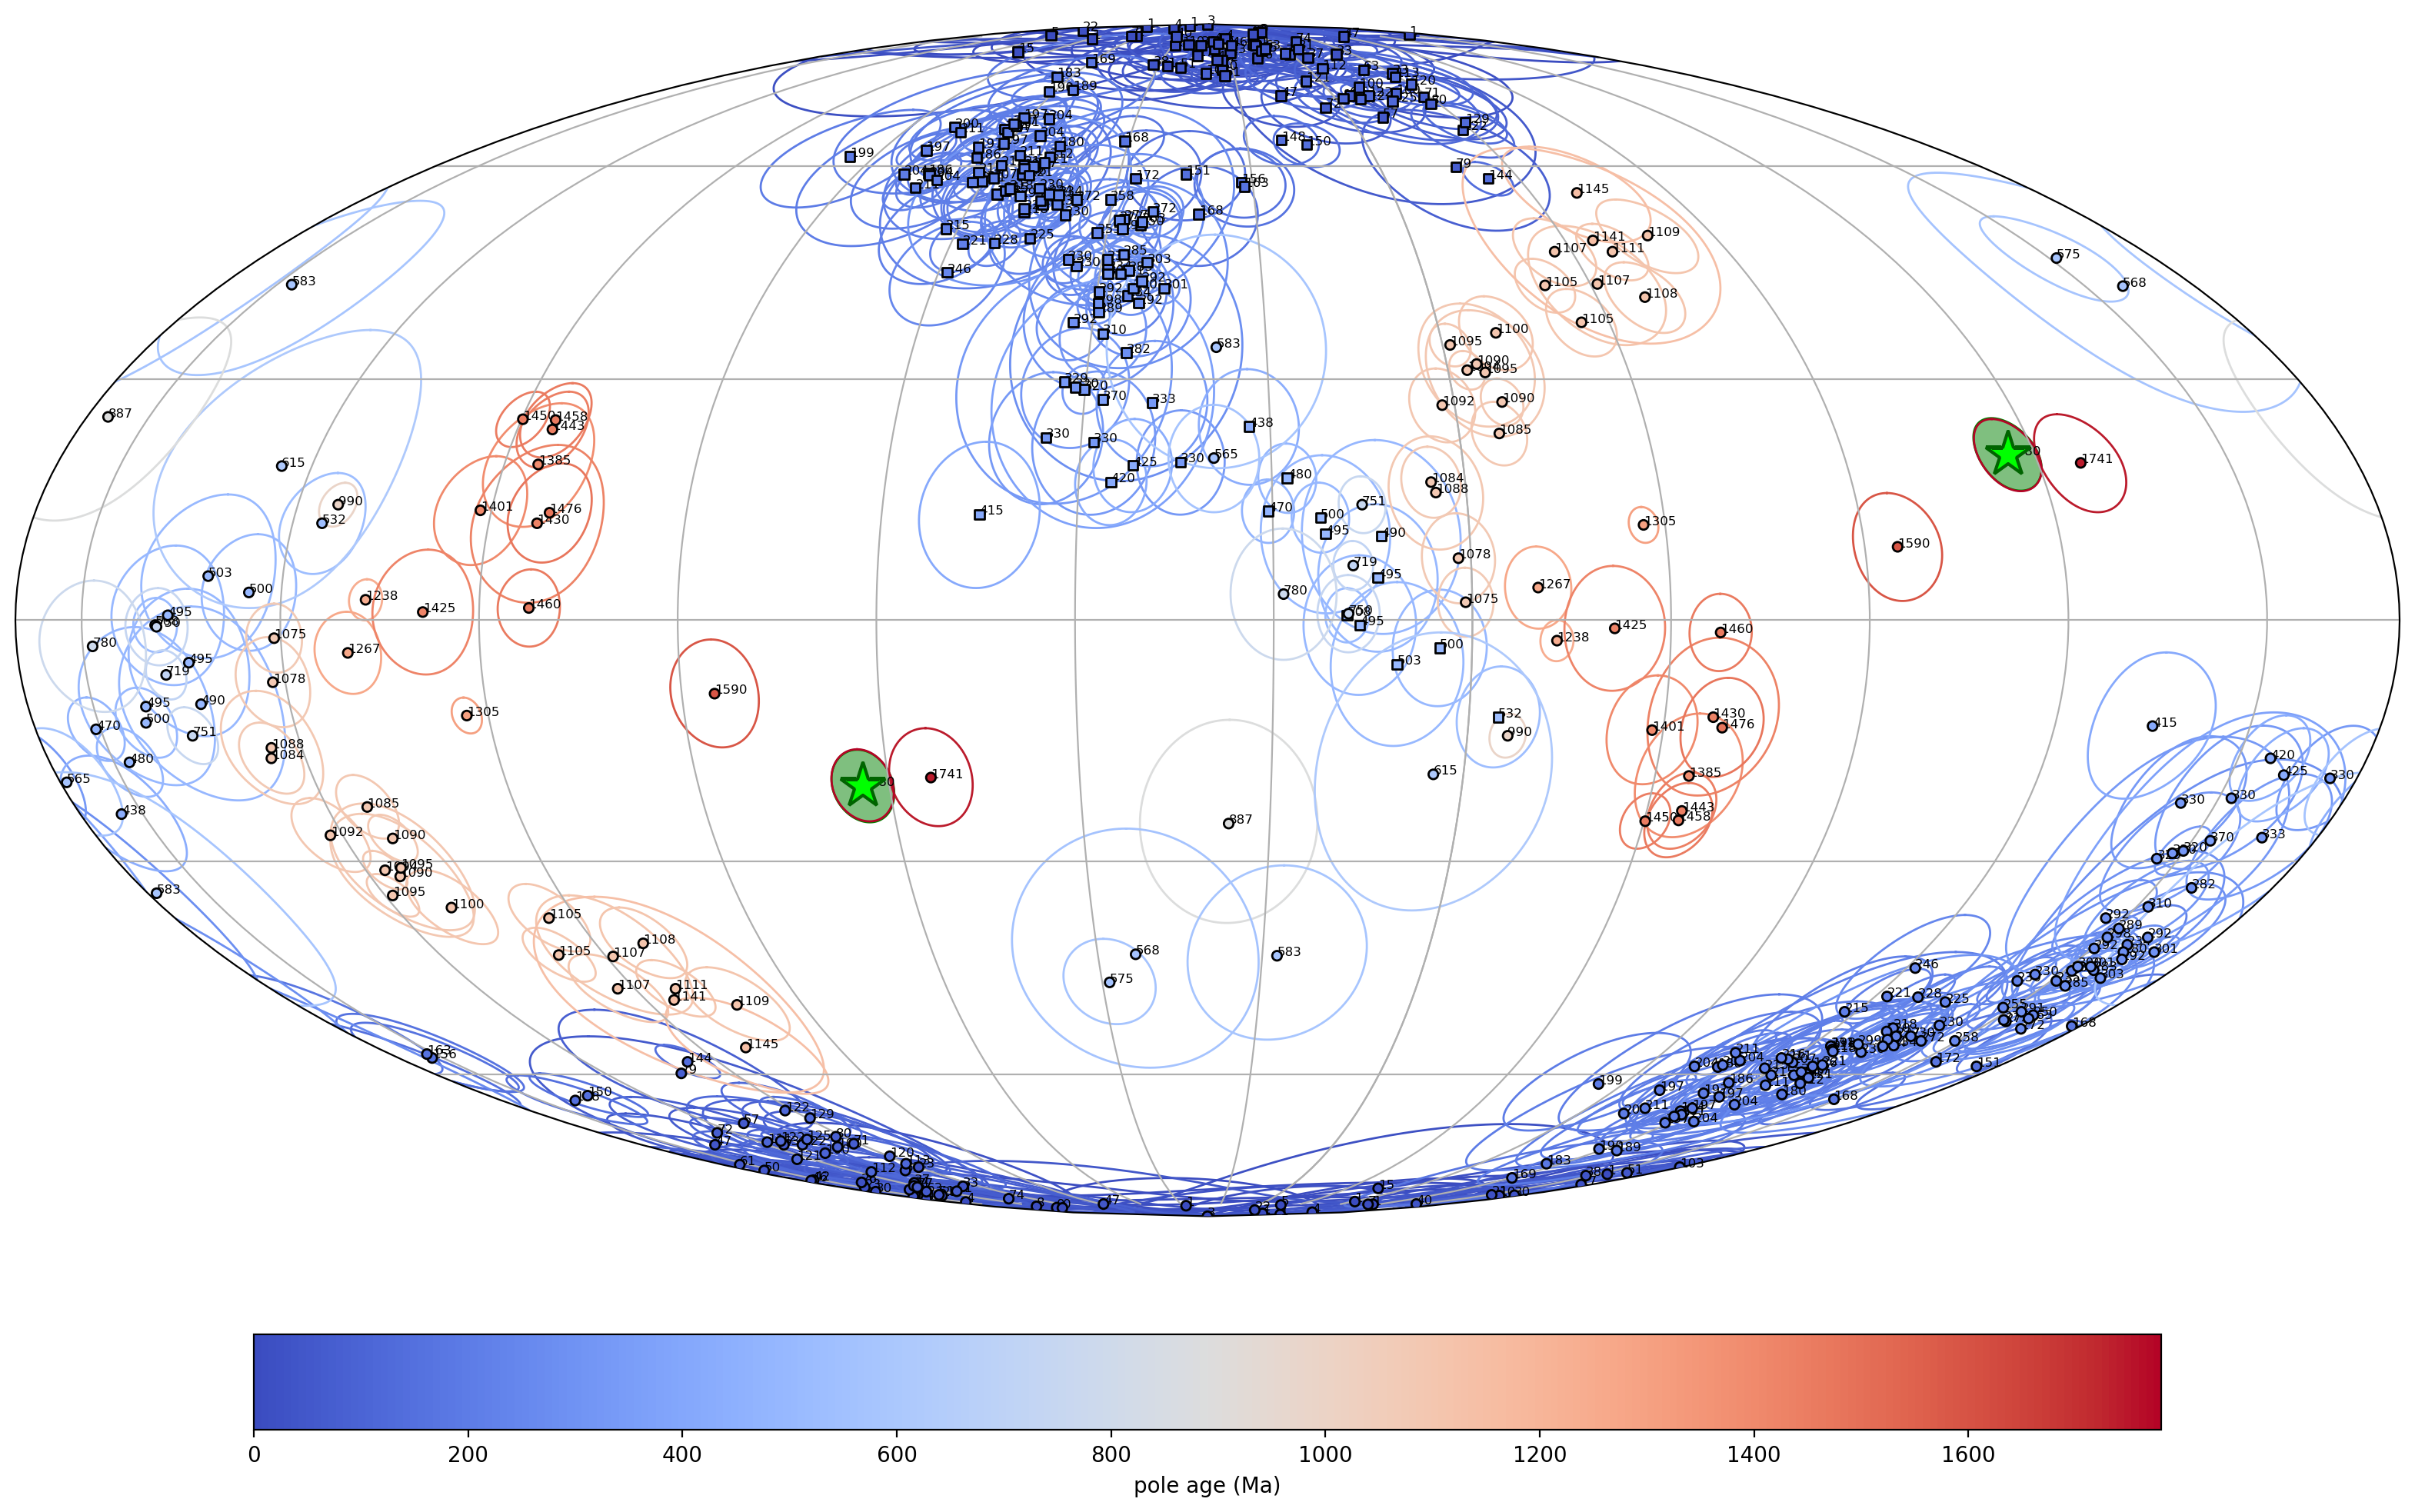

<GeoAxesSubplot:>

In [11]:
Laurentia_poles = pt.get_Laurentia_poles()
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('NE trending ECMB Diabase Dykes', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'])

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb dates constrain the dikes to 1779.1 ± 2.3 Ma (95% CI), bracketed between the St. Cloud Granite (1781.44 ± 0.51 Ma) they intrude and the Richmond Granite (1776.76 ± 0.49 Ma) they do not, with a comagmatic quartz–feldspar–porphyry dike at 1780.78 ± 0.45 Ma (Swanson-Hysell et al., 2021). |
| 2 | Techniques and statistical analysis | **1** | Sub-criterion (c) is met: N = 23 sites (148 samples, ≥ 3 per site), K = 45.6 (within 10–70), A95 = 4.5° passes the Deenen et al. (2011) envelope. AF and thermal demagnetization with PCA component analysis are documented in the source study (method codes are advisory). See `resources/Meert2020_R_criteria.md`. |
| 3 | Magnetic mineralogy characterized | **1** | The medium-coercivity ChRM unblocks thermally between 515°C and 565°C and is corroborated by low-temperature magnetometry, indicating a remanence carried by low-Ti titanomagnetite. |
| 4 | Field tests constrain age of magnetization | **1** | Positive **inverse baked contact test**: the *ca.* 1096 Ma northwest-trending Midcontinent Rift dike NWD1 cross-cuts and bakes the northeast-trending dike NED17, progressively overprinting the ECMB dike remanence toward the contact. This shows the ECMB dike magnetization predates *ca.* 1096 Ma and has not been overprinted since, supporting a primary origin. |
| 5 | Structural control / tectonic coherence | **1** | The dikes are within the autochthonous interior of the Superior Province; as near-vertical intrusions they require no tilt or inclination-shallowing correction. Thermochronology indicates only a mild post-emplacement thermal history. |
| 6 | Presence of reversals | **0** | The pole-bearing dike `mc` directions are of a single polarity; no reversal test is applied to the pole. |
| 7 | No resemblance to younger poles | **1** | The pole is distinct from all younger (Mesoproterozoic–Phanerozoic) Laurentia poles, and the positive inverse baked-contact test independently constrains the magnetization to predate *ca.* 1096 Ma. |
| | **Total R-score** | **6/7** | |

## Nordic workshop ranking

This pole was published after the Evans et al. (2021) *An expanding list of reliable paleomagnetic
poles for Precambrian tectonic reconstructions* compilation. At the 2022 Nordic Workshop in Kringdalen, this pole was assessed and given an 'A' rating.

In [12]:
ECMB_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='NE trending ECMB Diabase Dykes',
    sites=sites_pole,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Medium-coercivity (magnetite) characteristic remanent magnetization (ChRM)',
    tests='c+ (positive inverse baked contact test, NWD1 ca. 1096 Ma dike bakes NED17 = MagIC ST-C; Swanson-Hysell et al., 2021)',
    gpmdb_number='9970',
    magic_id='17072',
    percent_reversed=0,
    demag_code=4,
    R1=1,
    R2=1,
    R3=1,
    R4='c',
    R5=1,
    R6=0,
    R7=1,
    Grade='A',
    nominal_age=1779.1,
    lomagage=1776.8,
    himagage=1781.4,
    REF_method='New U-Pb dates bracket the dikes to 1779.1 ± 2.3 Ma (95% CI): younger than St. Cloud Granite (1781.44 ± 0.51 Ma), older than Richmond Granite (1776.76 ± 0.49 Ma) (Swanson-Hysell et al., 2021).',
    POLE_AUTHORS='Swanson-Hysell, N. L., Avery, M. S., Zhang, Y., Hodgin, E. B., Sherwood, R. J., Apen, F. E., Boerboom, T. J., Keller, C. B., & Cottle, J. M.',
    YEAR=2021,
    JOURNAL='Tectonics',
    VOLUME=40,
    VPAGES='e2021TC006751',
    TITLE='The paleogeography of Laurentia in its early years: new constraints from the Paleoproterozoic East-Central Minnesota Batholith',
    COMMENT='Pole recreated from the site level from the medium-coercivity (magnetite) ChRM of the NE-trending dikes (MagIC 17072), keeping site means with a95 < 8 deg (N=23, 148 samples); reproduces the published pole. Positive inverse baked contact test (NWD1/NED17).'
)
ECMB_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,NE trending ECMB Diabase Dykes,GPMDB:9970 MagIC:17072,Medium-coercivity (magnetite) characteristic r...,"c+ (positive inverse baked contact test, NWD1 ...",0,45.53,265.76,23,148,...,1781,New U-Pb dates bracket the dikes to 1779.1 ± 2...,NE trending ECMB Diabase Dykes,"Swanson-Hysell, N. L., Avery, M. S., Zhang, Y....",2021,Tectonics,40,e2021TC006751,The paleogeography of Laurentia in its early y...,Pole recreated from the site level from the me...


In [13]:
# save the summary as a single-row CSV in data/nordic_summaries
pt.save_nordic_summary(ECMB_summary, '1779_East_Central_Minnesota_Batholith')

'../data/nordic_summaries/1779_East_Central_Minnesota_Batholith.csv'